### Autors

Ziyi Hong - *2694933*

Danylo Tulainov - *5070969*

# Laborarbeit Teil 1

## Datensatz

In diesem Notebook werden Sie selbstständig mit dem Datensatz `passengers-dataset.csv` arbeiten.

Der Datensatz enthält Passagierdaten eines historischen Schiffsunglücks. Das sind die Spalten der Datei:
* PassengerID: Passagier-ID
* Survived: Indikator ob Passagier überlebt hat (1=ja, 0=nein)
* Pclass: Ticketklasse 
* Name: Name des Passagiers
* Sex: Geschlecht des Passagiers
* Age: Alter des Passagiers
* SibSp: Zahl der Geschwister und Ehepartner eines Passagiers an Bord
* Parch: Zahl der Elternteile und Kinder eines Passagiers an Bord
* Ticket: Ticket-ID
* Fare: Ticketpreis
* Cabin: Kabine des Passagiers
* Embarked: Zustiegshafen (C=Cherbourg, Frankreich; Q=Queenstown, Irland; S=Southampton, Großbritannien)

## Aufgabe

**Ihre Aufgabe ist es ein möglichst gutes Modell zu entwickeln, das vorhersagt, ob ein Passagier überlebt.**

## Hinweise

Die Aufgabenstellung ist bewusst offen gehalten. Berücksichtigen Sie bei der Bearbeitung der Aufgabe die folgenden Hinweise:
* Dokumentieren Sie Ihr Vorgehen strukturiert und nachvollziehbar.
* Begründen Sie Ihre Vorgehensweise und Entscheidungen.
* Interpretieren Sie Ergebnisse.
* Erstellen Sie, wo möglich und sinnvoll, Plots.
* **Nutzen Sie nur Methoden, Konzepte und Begründungen, die in der Vorlesung behandelt wurden. Falls dies nicht möglich ist, begründen Sie warum.**
* Identifizieren Sie Schwachstellen/Limitationen Ihrer Arbeit und erläutern Sie diese auf Basis der Vorlesungsinhalte.

Berücksichtigen Sie die folgenden Hinweise für die Abgabe:
* Arbeiten Sie in 2er-Gruppen und geben Sie je Gruppe ein Notebook ab.
* Nennen Sie im abgegebenen Notebook die Gruppenmitglieder.
* **Für die Verwendung von KI berücksichtigen Sie die Hinweise von Herrn Prof. Hänisch.**
* Die erste Abgabe muss am Dienstag, den 17.03., zwischen 15:30 und 16:15 Uhr per Moodle erfolgen.
* Die endgültige Abgabe muss bis Dienstag, den 24.03., um 23:59 Uhr per Moodle erfolgen.
* Gewertet wird die endgültige Abgabe. Wenn Sie zwischen erster und endgültiger Abgabe Änderungen vornehmen, müssen Sie diese begründen.

## Data Understanding

The first step of creating the machine learning model - according to **Crisp-DM** - is *Data Understanding*.

At this stage the following work will be done:
- Load of dataset
- Drop of non-relevant features
- Store the target feature to `y` and training features to `X`
- Feature Engineering:
  - Count the missing values
  - Find numerical and categorical features
  - `One-Hot-Encoding` for categorical
  - Find correlating features
  - Outline top features


Since the work is done in Google Colab, the datasets are stored on Drive. To grant the permissions to Drive - the following code is necessary

Import packages

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score


In [2]:
# load data into dataframe
file_path = 'passengers-dataset.csv'
df = pd.read_csv(file_path)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


`df.info()` helps to see the features of dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


#### Drop the columns

It was decided that `PassengerId`, `Name`, and `Ticket` are irrelevant to the target value.

In [4]:
df = df.drop(columns=["PassengerId", "Name", "Ticket"], errors="ignore")
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


#### Separation of features from target

This step is made to separate training features from target.
Target is saved to `y`, training to `X`.

In [5]:
y = df["Survived"]
X = df.drop(columns=["Survived"])

# number of examples and features
X.shape

(891, 8)

#### Find missing values

The next step is crucial in *feature engineering*.
If the model is trained with missing values, its results will interfere with the analysis and final predictions.

In [6]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]
missing_counts

Cabin       687
Age         177
Embarked      2
dtype: int64

#### Find numerical data and categorical data

Another important step of *feature engineering*.

In [7]:
# numerical
numerical_data = X.select_dtypes("number")
numerical_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pclass  891 non-null    int64  
 1   Age     714 non-null    float64
 2   SibSp   891 non-null    int64  
 3   Parch   891 non-null    int64  
 4   Fare    891 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 34.9 KB


In [8]:
# categorical
string_data = X.select_dtypes(object)
string_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Sex       891 non-null    object
 1   Cabin     204 non-null    object
 2   Embarked  889 non-null    object
dtypes: object(3)
memory usage: 21.0+ KB


#### find the unique categories per categorical features

In [9]:
num_categories = string_data.nunique().sort_values(ascending=False)
num_categories

Cabin       147
Embarked      3
Sex           2
dtype: int64

#### Drop the `cabin` feature:

`cabin` feature is the most problematic feature in dataset. Not only it has 147 unique categories, 687 rows are `null`. To prevent the learning process from this feature -> it was decided to drop it from dataset.

In [10]:
df_clean = df.drop(columns=["Cabin"], errors="ignore")
df_clean.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


#### `One-hot-encoding`

Categorical features are transformed via **One-hot-encoding** and `get_dummies()` method. This step ensures that dataset is properly formatted for correlation analysis.

In [11]:
df_encoded = pd.get_dummies(df_clean, drop_first=True)
df_encoded

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True
...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,True,False,True
887,1,1,19.0,0,0,30.0000,False,False,True
888,0,3,NaN,1,2,23.4500,False,False,True
889,1,1,26.0,0,0,30.0000,True,False,False


#### Corrrelation

Correlation helps identify relationships between features and find out which features are most influential for the target variable `y`.

In [12]:
# correlation matrix
corr_matrix = df_encoded.corr()

# correlation with target variable
corr_with_target = corr_matrix["Survived"].sort_values(ascending=False)
top_features = corr_with_target[1:10]
top_features

Fare          0.257307
Parch         0.081629
Embarked_Q    0.003650
SibSp        -0.035322
Age          -0.077221
Embarked_S   -0.155660
Pclass       -0.338481
Sex_male     -0.543351
Name: Survived, dtype: float64

#### Find the top features

Find the top features and check whether each one belongs to numerical or categorical. It is a validation step to confirm the nature of the most significant features.

In [13]:
# names of top features
top_feature_names = top_features.index

# numerical columns in X
numeric_cols = numerical_data.columns

# check: numerical or categorical
for feature in top_feature_names:
    if feature in numeric_cols:
        print(f"{feature}: numerical")
    else:
        print(f"{feature}: categorical")

Fare: numerical
Parch: numerical
Embarked_Q: categorical
SibSp: numerical
Age: numerical
Embarked_S: categorical
Pclass: numerical
Sex_male: categorical


## Data preparation

The next stage of **CRISP-DM** is *Data Preparation*.

This stage consists of following steps:
- Selecting features for training
- One hot encoding of categorical features
- Find missing values in selected features
- Replacing missing values
- Division of data into training and testing sets
- Feature scaling

In [14]:
selected_features = [
    "Sex_male",
    "Pclass",
    "Fare",
    "Age",
    "Embarked_S",
]


#### One hot encoding

At the *Data Understanding* stage `One-hot-encoding` was made to the whole dataframe for the sake of finding correlation.
Here, at this stage, it is done for categorical features in `X`which will be used for training of the model.

In [15]:
# one-Hot-Encoding categorical features
X = pd.get_dummies(X, drop_first=True)
X

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Cabin_A14,Cabin_A16,Cabin_A19,Cabin_A20,...,Cabin_F G63,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,1,38.0,1,0,71.2833,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,26.0,0,0,7.9250,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,1,35.0,1,0,53.1000,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,3,35.0,0,0,8.0500,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,27.0,0,0,13.0000,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
887,1,19.0,0,0,30.0000,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
888,3,NaN,1,2,23.4500,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
889,1,26.0,0,0,30.0000,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


#### Load selected features into `X`

In [16]:
# select
X = X[selected_features]
X.head()

,Sex_male,Pclass,Fare,Age,Embarked_S
0,True,3,7.2500,22.0,True
1,False,1,71.2833,38.0,False
2,False,3,7.9250,26.0,True
3,False,1,53.1000,35.0,True
4,True,3,8.0500,35.0,True


#### Find and replace missing values

The next step's code finds and replaces missing values in chosen features.
Replacement happens in feature `Age` with **median** value.

In [17]:
# find missing
missing_counts = X.isna().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]
missing_counts

# Replace missing values in age with median
print(X['Age'].median())

X = X.copy()
X["Age"] = X["Age"].fillna(X['Age'].median())

X.isna().sum()


28.0


Sex_male      0
Pclass        0
Fare          0
Age           0
Embarked_S    0
dtype: int64

#### Train-test split

The data is prepared for learning. In the following code the data is splitted to train and test in percentage 80/20.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape)

(712, 5)


#### Cross validation

Cross validation improves the reliability of the model. This process ensure that data points serve both as training and validation data at different stages, and reduces the risk of overfitting.

In [19]:
# X_train_sub, X_val, y_train_sub, y_val = train_test_split(
#     X_train, y_train,
#     test_size=0.25,
#     random_state=42,
#     stratify=y_train
# )

# print(X_train_sub.shape)
# print(X_val.shape)
# print(X_test.shape)

#### Feature scaling

This step scales the data for better comparison and improves stability during training. Scaling is implemented using the `StandartScaler` from `scikit-learn` library, which applies *Z-score-normalization*.

In [20]:
# scaler = StandardScaler()

# # fit only on the training sub-set
# X_train_sub = scaler.fit_transform(X_train_sub)

#### Transform validation and test sets using the training parameters

In [21]:
# X_val = scaler.transform(X_val)
# X_test = scaler.transform(X_test)

## Modeling

The next stage in **CRISP-DM** is *Modeling*.

This stage consists of following steps:
- Model comparison using pipelines
- Hyperparameter tuning
- Model evaluation
- Model training
- Model scaling
- Performance assessment

#### Model Comparison using pipelines

In this code snippet multiple `Pipeline` objects are defined to streamline and model execution. Each pipeline bundles feature engineering steps directly with a specific classifier like `Logistic Regression`, `SVC`, `MLPClassifier`.

Cross-validation is performed using `StratifieldKFold`. Process  calculates the mean accuracy and standartd deviation for each model, which serves as the basis for selecting __the most effective algorithm__.

In [22]:
# compare models and choose the best models using scikit learn

pipe_log = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(penalty="l2", max_iter=1000))
])


pipe_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42, max_iter=1000))
])

pipe_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(hidden_layer_sizes=10, random_state=42, max_iter=1000))
])

pipe_tree = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", DecisionTreeClassifier(random_state=42, max_depth=4))
])

# dictionary for all the pipelines
pipelines = {
    "log reg": pipe_log,
    "mlp": pipe_mlp,
    "svc": pipe_svc,
    "tree": pipe_tree,
}


# cross validation and compare the scores of those pipelines
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")
    print(f"{name}: {scores.mean()}, ±, {scores.std()}")


log reg: 0.8202009258347287, ±, 0.01940958055294648


/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/hong/Study/DHBW/Semester5/DT/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated

mlp: 0.8089727174234216, ±, 0.018725806954116984
svc: 0.825824879346006, ±, 0.020714131769674456
tree: 0.8146262188515709, ±, 0.017266240098342434


We choose to go on with decision tree as the first model.

## Decision Tree

In [23]:
# svc and tree has better avergae accuracy

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report



tree_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

tree_gini.fit(X_train, y_train)

print("Train accuracy:", accuracy_score(y_train, tree_gini.predict(X_train)))
print("Test accuracy :", accuracy_score(y_test, tree_gini.predict(X_test)))


print(classification_report(y_test, tree_gini.predict(X_test), target_names=["dead", "survived"]))

Train accuracy: 0.8314606741573034
Test accuracy : 0.776536312849162
              precision    recall  f1-score   support

        dead       0.77      0.92      0.83       110
    survived       0.81      0.55      0.66        69

    accuracy                           0.78       179
   macro avg       0.79      0.73      0.74       179
weighted avg       0.78      0.78      0.77       179



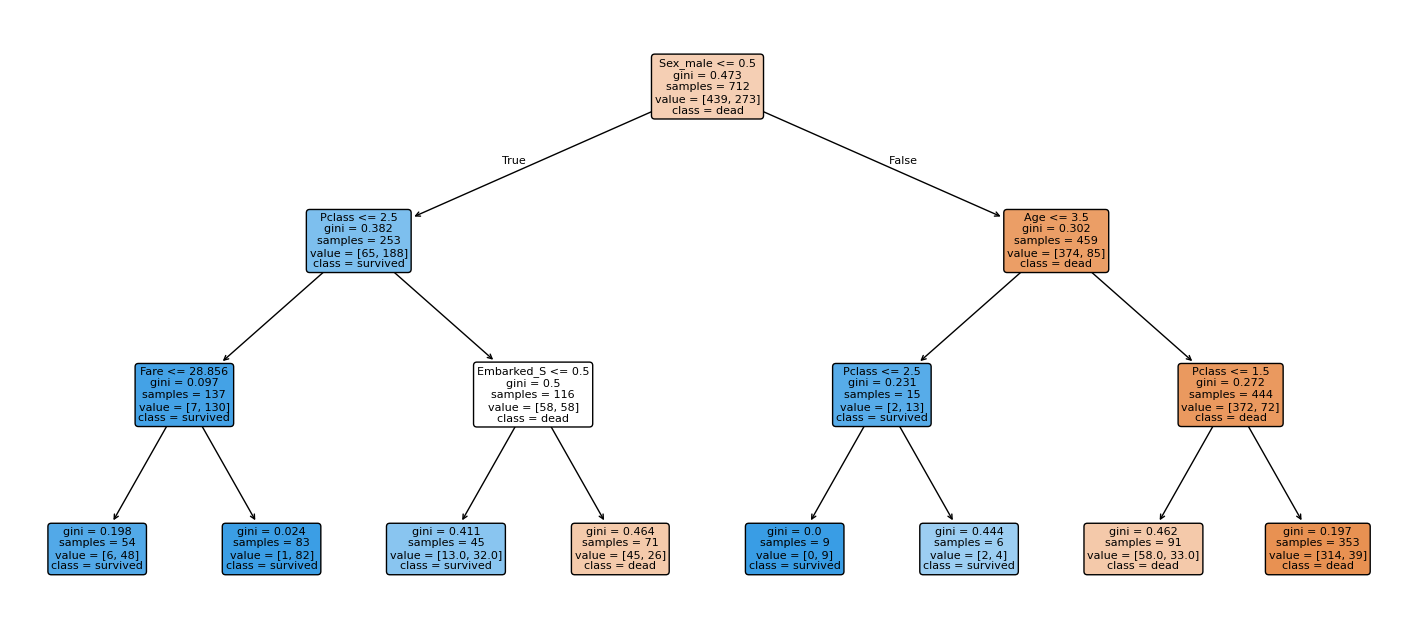

In [24]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 8))
plot_tree(
    tree_gini,
    feature_names=X.columns,
    class_names=["dead", "survived"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

In [25]:
print(classification_report(y_test, tree_gini.predict(X_test), target_names=["dead", "survived"]))

              precision    recall  f1-score   support

        dead       0.77      0.92      0.83       110
    survived       0.81      0.55      0.66        69

    accuracy                           0.78       179
   macro avg       0.79      0.73      0.74       179
weighted avg       0.78      0.78      0.77       179



To find the best depths, we *scaler* the features and split the dataset into  *train, validation, test*

In [26]:
depths = range(1, 16)

train_scores = []
val_scores = []

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

# scalierung
scaler = StandardScaler()
X_train_sub = scaler.fit_transform(X_train_sub)
X_val = scaler.transform(X_val)

for depth in depths:
    tree_depth = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )
    tree_depth.fit(X_train_sub, y_train_sub)

    train_scores.append(accuracy_score(y_train_sub, tree_depth.predict(X_train_sub)))
    val_scores.append(accuracy_score(y_val, tree_depth.predict(X_val)))

depth_results = pd.DataFrame({
    "max_depth": list(depths),
    "train_accuracy": train_scores,
    "validation_accuracy": val_scores
})

depth_results

,max_depth,train_accuracy,validation_accuracy
0,1,0.786517,0.797753
1,2,0.803371,0.808989
2,3,0.825843,0.848315
3,4,0.842697,0.831461
4,5,0.859551,0.831461
5,6,0.872659,0.825843
6,7,0.893258,0.792135
7,8,0.908240,0.831461
8,9,0.932584,0.797753
9,10,0.947566,0.797753


Beste Validation-Accuracy bei max_depth = 3
Beste Validation-Accuracy: 0.8483


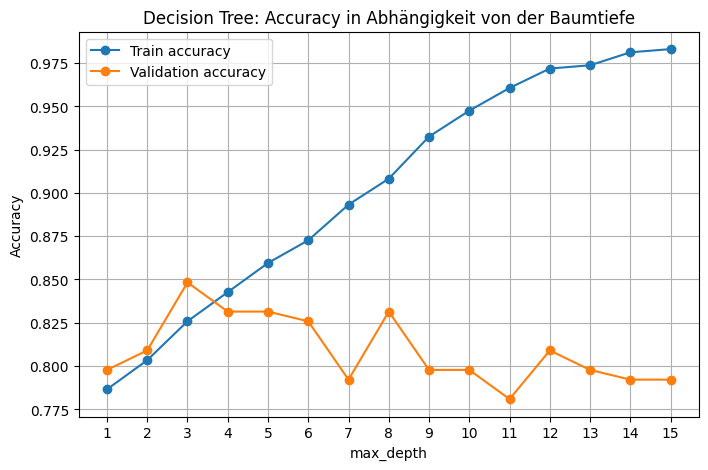

In [27]:
best_depth = depth_results.loc[depth_results["validation_accuracy"].idxmax(), "max_depth"]
best_val_accuracy = depth_results["validation_accuracy"].max()

print("Beste Validation-Accuracy bei max_depth =", best_depth)
print("Beste Validation-Accuracy:", round(best_val_accuracy, 4))

plt.figure(figsize=(8, 5))
plt.plot(depth_results["max_depth"], depth_results["train_accuracy"], marker="o", label="Train accuracy")
plt.plot(depth_results["max_depth"], depth_results["validation_accuracy"], marker="o", label="Validation accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Accuracy in Abhängigkeit von der Baumtiefe")
plt.xticks(list(depths))
plt.grid(True)
plt.legend()
plt.show()


Here we use the best max_depth=3, and use *cross validation* to see the final test accuracy

In [28]:
tree_tuned = DecisionTreeClassifier(
    criterion="gini",
    max_depth=best_depth,
    random_state=42
)
tree_tuned.fit(X_train, y_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(tree_tuned, X, y, cv=cv, scoring="accuracy")

print("Tree test mean accuracy:", scores.mean(), "±", scores.std())

Tree test mean accuracy: 0.8136902893729208 ± 0.012537265038300872


### Decision Tree -> Random Forest

Since we used decision tree, we want to see whether random forest will achieve a better result.

This step defines a search space for model parameters and evaluates multiple configurations.

The loop trains a new `RandomForestClassifier` for every combination of `n_estimators` and `max_depth`.

In [ ]:
rf_results = []

n_estimators_list = [10, 50, 100]
max_depth_list = [3, 5, 10, None]

for n_estimators in n_estimators_list:
    for max_depth in max_depth_list:
        rf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42
        )
        rf.fit(X_train_sub, y_train_sub)

        train_acc = accuracy_score(y_train_sub, rf.predict(X_train_sub))
        val_acc = accuracy_score(y_val, rf.predict(X_val))

        rf_results.append({
            "n_estimators": n_estimators,
            "max_depth": max_depth,
            "train_accuracy": train_acc,
            "val_accuracy": val_acc
        })

rf_results = pd.DataFrame(rf_results)
rf_results

,n_estimators,max_depth,train_accuracy,val_accuracy
0,10,3.0,0.831461,0.831461
1,10,5.0,0.859551,0.820225
2,10,10.0,0.951311,0.820225
3,10,NaN,0.970037,0.792135
4,50,3.0,0.825843,0.808989
5,50,5.0,0.861423,0.825843
6,50,10.0,0.955056,0.837079
7,50,NaN,0.985019,0.792135
8,100,3.0,0.833333,0.820225
9,100,5.0,0.874532,0.825843


#### Selection of best parameters

Initialization of the final model instance. This step extracts the optimal values for the number of trees and maximum depth.

In [30]:
best_rf_row = rf_results.loc[rf_results["val_accuracy"].idxmax()]
best_rf_row

n_estimators      50.000000
max_depth         10.000000
train_accuracy     0.955056
val_accuracy       0.837079
Name: 6, dtype: float64

In [31]:
best_rf = RandomForestClassifier(
    n_estimators=int(best_rf_row["n_estimators"]),
    max_depth=int(best_rf_row["max_depth"]),
    random_state=42
)

In [32]:
# X_train_final, X_test_final, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# X_train_final_scaled = scaler.fit_transform(X_train_final)
# X_test_final_scaled = scaler.transform(X_test_final)

#### Final model training and assessment

The final model is trained on the complete and scaled training set. Once it's ready, a calculation of the accuracy on the held-out test follows. The resulting value represents the final performance metric.

In [33]:
best_rf.fit(X_train, y_train)

rf_test_accuracy = accuracy_score(y_test, best_rf.predict(X_test))
print("Test Accuracy of the best Random Forest:", round(rf_test_accuracy, 4))

Test Accuracy of the best Random Forest: 0.8212


## Evaluation

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(best_rf,X,y,cv=cv,scoring="accuracy")

print("Accuracy pro Fold:", scores)

print("Mean Accuracy:", scores.mean(), "±", scores.std())

Accuracy pro Fold: [0.84357542 0.83146067 0.83146067 0.8258427  0.84831461]
Mean Accuracy: 0.8361308141359614 ± 0.008406339517628536


| Model | Mean Accuracy | Std Dev |
|---|---|---|
| **Random Forest** | **0.8361** | ±0.0084 |
| SVC (RBF kernel) | 0.8258 | ±0.0207 |
| Logistic Regression | 0.8202 | ±0.0194 |
| Decision Tree | 0.8146 | ±0.0173 |
| MLP | 0.8090 | ±0.0188 |

*Random Forest* achieves the highest mean accuracy and also the lowest standard deviation, making it both the most accurate and the most stable model across all folds.


# Limitation #

The best model: Random Forest has only 83% mean accuracy.

Why?
1. Small Dataset
2. Feature selection might be bad. There are only 5 features selected.
    - for example: Parch, SibSp can be a useful feature, which shows many children and family member they have.
3. 